In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [2]:
# Load the Titanic dataset
filepath = 'train.csv'
df = pd.read_csv(filepath)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.shape)
df.info()
df.describe()
print(df.columns.tolist())


(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_percent.round(2)
})
missing_summary[missing_summary['Missing Count'] > 0]


,Missing Count,Missing %
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [5]:
for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(df[col].value_counts())


Survived
0    549
1    342
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


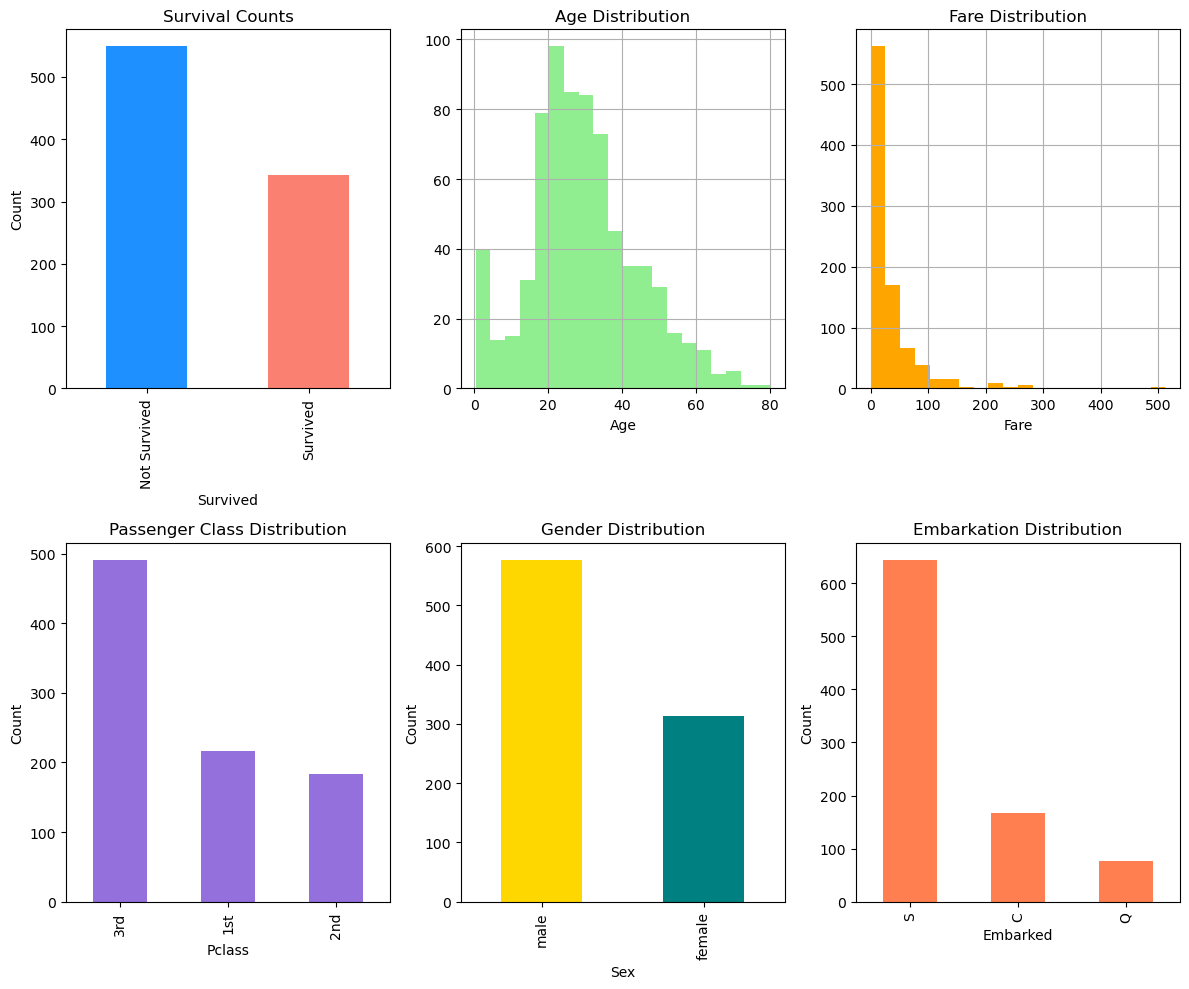

In [6]:
plt.figure(figsize=(12,10))
plt.subplot(231)
df['Survived'].value_counts().plot(kind='bar', color=['dodgerblue','salmon'])
plt.title('Survival Counts')
plt.ylabel('Count')
plt.xticks([0,1], ['Not Survived','Survived'])

plt.subplot(232)
df['Age'].hist(bins=20, color='lightgreen')
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(233)
df['Fare'].hist(bins=20, color='orange')
plt.title('Fare Distribution')
plt.xlabel('Fare')

plt.subplot(234)
df['Pclass'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Passenger Class Distribution')
plt.ylabel('Count')
plt.xticks([0,1,2], ['3rd','1st','2nd'])

plt.subplot(235)
df['Sex'].value_counts().plot(kind='bar', color=['gold','teal'])
plt.title('Gender Distribution')
plt.ylabel('Count')

plt.subplot(236)
df['Embarked'].value_counts().plot(kind='bar', color='coral')
plt.title('Embarkation Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


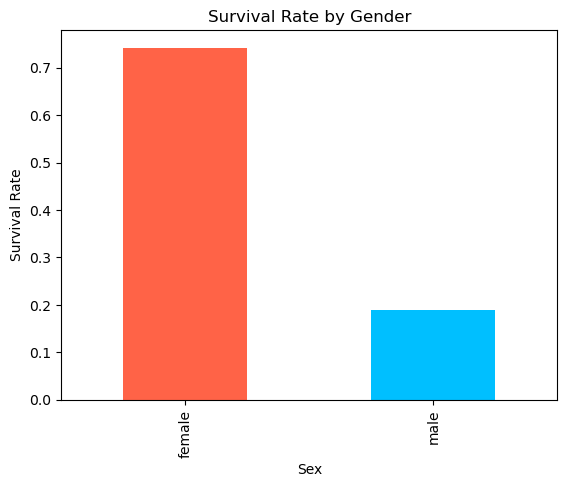

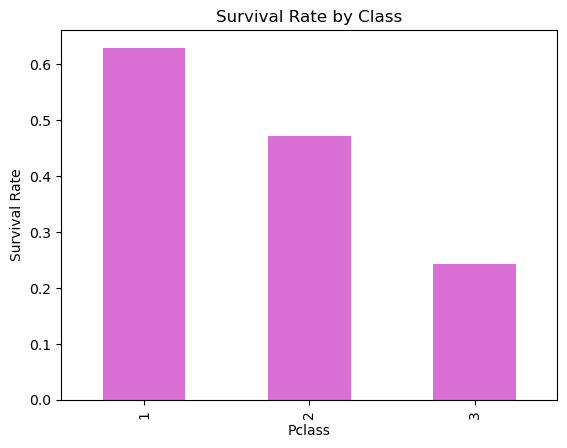

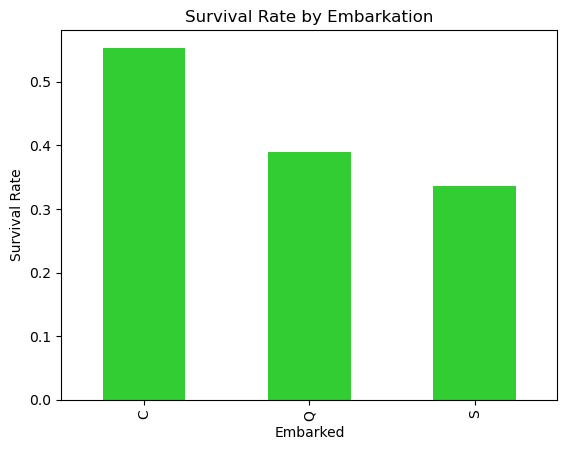

In [7]:
# Survival by gender
survival_by_gender = df.groupby('Sex')['Survived'].mean()
survival_by_gender.plot(kind='bar', color=['tomato','deepskyblue'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

# Survival by class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
survival_by_class.plot(kind='bar', color='orchid')
plt.title('Survival Rate by Class')
plt.ylabel('Survival Rate')
plt.show()

# Survival by embarkation
survival_by_embarked = df.groupby('Embarked')['Survived'].mean()
survival_by_embarked.plot(kind='bar', color='limegreen')
plt.title('Survival Rate by Embarkation')
plt.ylabel('Survival Rate')
plt.show()


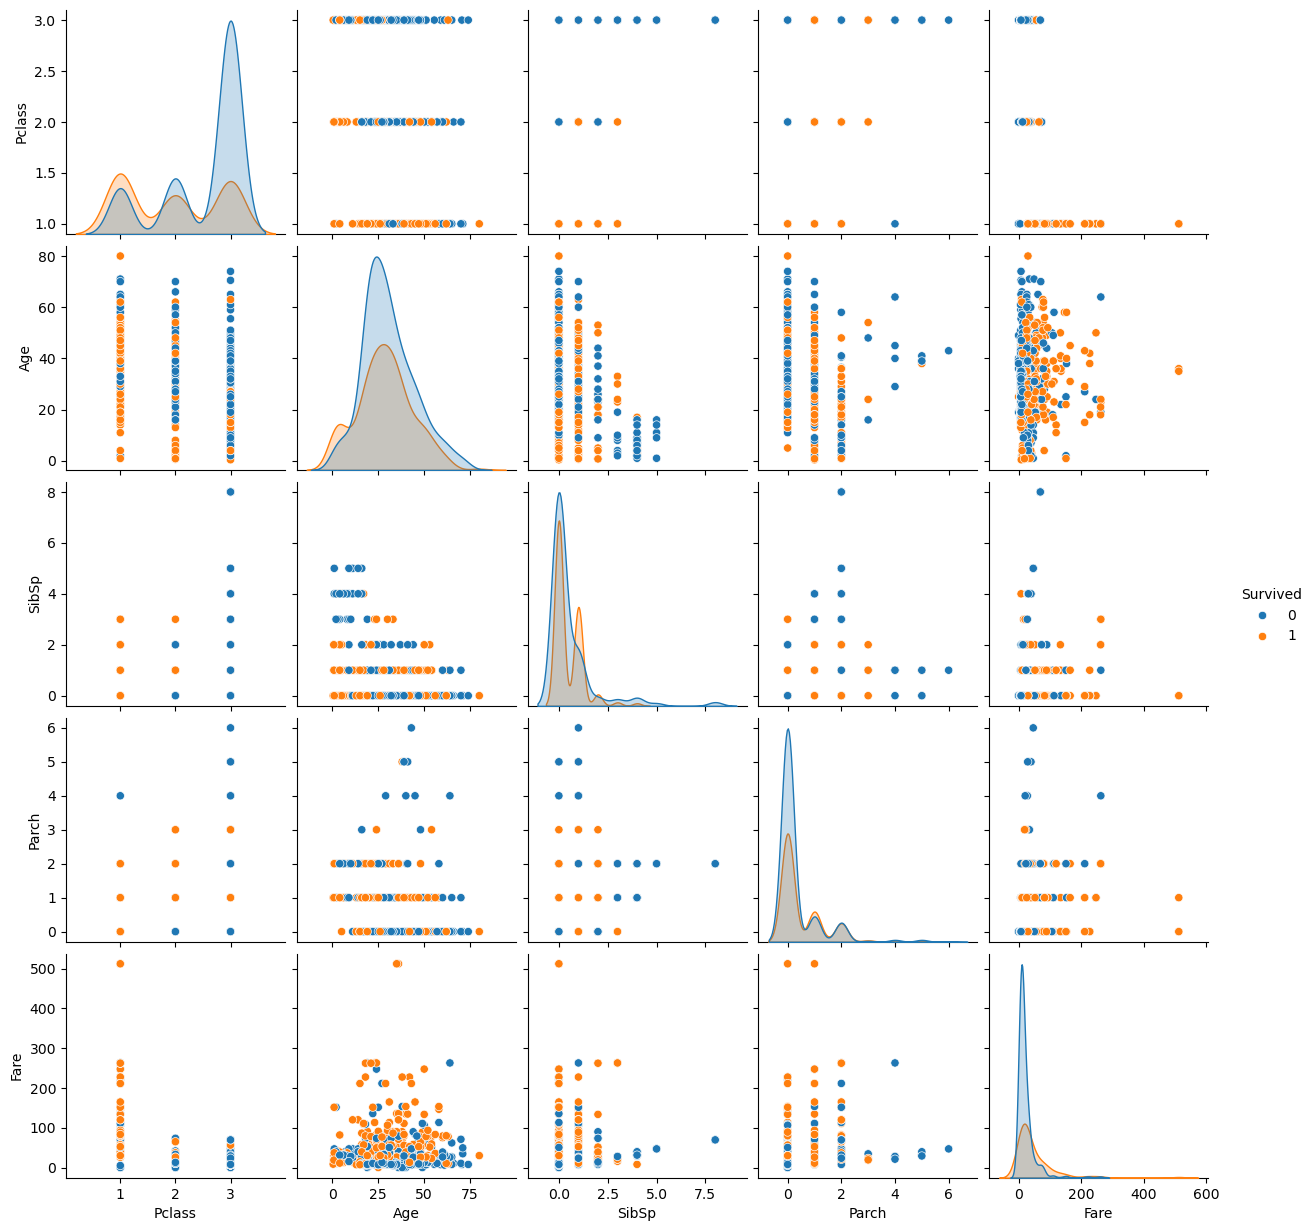

In [16]:
sns.pairplot(df[['Survived','Pclass','Age','SibSp','Parch','Fare']], hue='Survived')
plt.show()


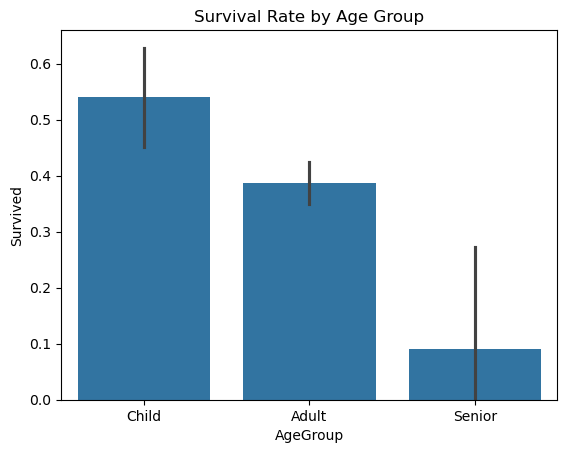

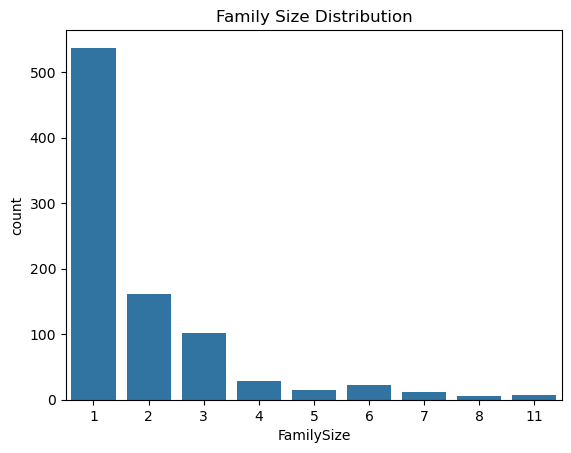

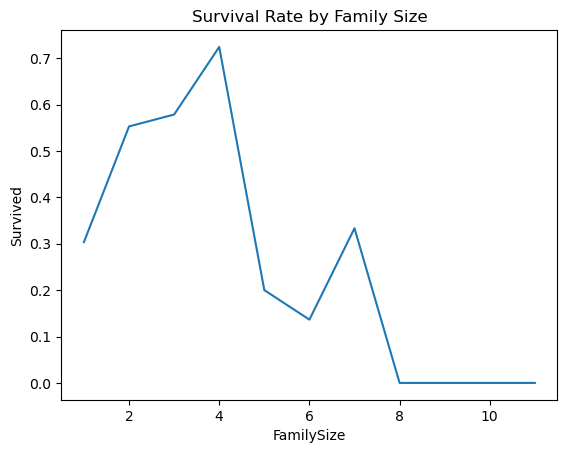

In [8]:
# Survival by age group
bins = [0,18,65,100]
labels = ['Child','Adult','Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
sns.barplot(x='AgeGroup',y='Survived',data=df)
plt.title('Survival Rate by Age Group')
plt.show()

# Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
sns.countplot(x='FamilySize',data=df)
plt.title('Family Size Distribution')
plt.show()
sns.lineplot(x='FamilySize',y='Survived',data=df.groupby('FamilySize')['Survived'].mean().reset_index())
plt.title('Survival Rate by Family Size')
plt.show()


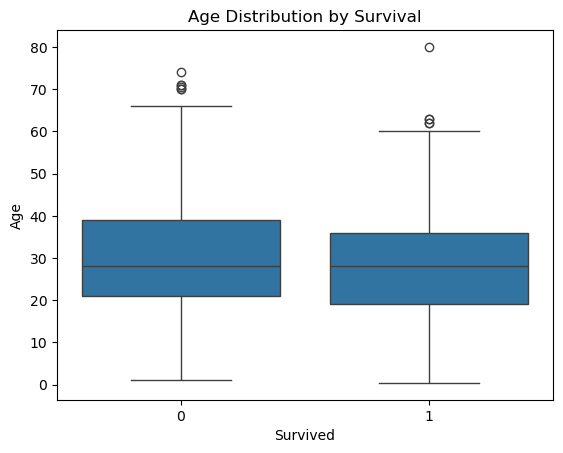

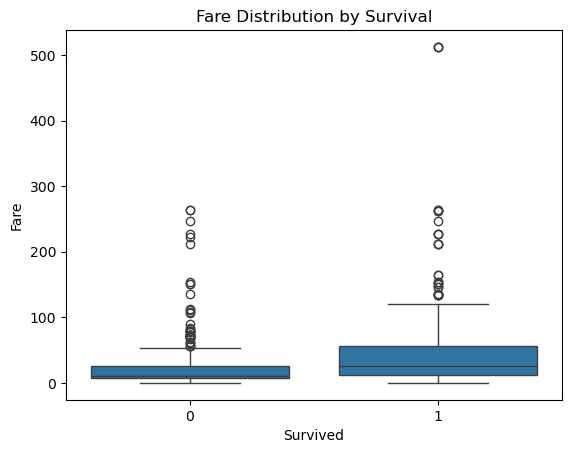

In [14]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.show()
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()


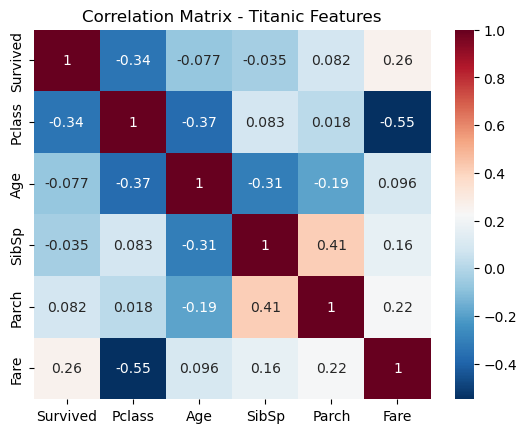

In [9]:
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r')
plt.title('Correlation Matrix - Titanic Features')
plt.show()


In [10]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Fare']<lower)|(df['Fare']>upper)]
print("Number of Fare Outliers:", len(outliers))
print("Top 5 Highest Fares:")
print(df.nlargest(5,'Fare')[['Name','Pclass','Sex','Age','Fare','Survived']])


Number of Fare Outliers: 116
Top 5 Highest Fares:
                                   Name  Pclass     Sex   Age      Fare  \
258                    Ward, Miss. Anna       1  female  35.0  512.3292   
679  Cardeza, Mr. Thomas Drake Martinez       1    male  36.0  512.3292   
737              Lesurer, Mr. Gustave J       1    male  35.0  512.3292   
27       Fortune, Mr. Charles Alexander       1    male  19.0  263.0000   
88           Fortune, Miss. Mabel Helen       1  female  23.0  263.0000   

     Survived  
258         1  
679         1  
737         1  
27          0  
88          1  


In [11]:
print("Overall survival rate:",df['Survived'].mean())
print("Survival by gender:",df.groupby('Sex')['Survived'].mean())
print("Survival by class:",df.groupby('Pclass')['Survived'].mean())
print("Survival by family size:",df.groupby('FamilySize')['Survived'].mean())
print("Survival by embarkation:",df.groupby('Embarked')['Survived'].mean())


Overall survival rate: 0.3838383838383838
Survival by gender: Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival by class: Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Survival by family size: FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64
Survival by embarkation: Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [13]:
summary_stats = pd.DataFrame({
    'Metric': ['Overall Survival Rate', 'Female Survival Rate', 'Male Survival Rate', 
               'Class 1 Survival Rate', 'Class 3 Survival Rate', 'Child Survival Rate'],
    'Value': [f"{df['Survived'].mean():.1%}", 
              f"{df[df['Sex']=='female']['Survived'].mean():.1%}",
              f"{df[df['Sex']=='male']['Survived'].mean():.1%}",
              f"{df[df['Pclass']==1]['Survived'].mean():.1%}",
              f"{df[df['Pclass']==3]['Survived'].mean():.1%}",
              f"{df[df['AgeGroup']=='Child']['Survived'].mean():.1%}"]
})
summary_stats.to_csv('titanic_eda_summary.csv', index=False)
